# 12 · Phosphorus

Compare maize grain yield at 0, 20 and 40 kg P/ha in Wa, Ghana, while holding nitrogen at 120 kg N/ha.

## You will learn

- Read the FileX soil-analysis P and keep it fixed across scenarios.
- Enable phosphorus simulation and supply elemental P in a fertilizer schedule.
- Compare grain yield and crop growth across P rates with the same nitrogen inputs.

In [1]:
LESSON = "12_phosphorus"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load tools for tables and inline plots.

In [3]:
# Load the lesson tools.
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: tables and plots.")

Tools ready: tables and plots.


Select the stock Wa inputs and preview treatment 7, the common starting point for all P scenarios.

In [4]:
# Select the copied inputs and show the starting treatment.
inputs = {
    "filex": RUNS / "GHWA0401.MZX",
    "weather": [RUNS / "GHWA0301.WTH", RUNS / "GHWA0401.WTH"],
    "soil": RUNS / "GH.SOL",
    "executable": dssat,
}
lines = inputs["filex"].read_text(encoding="utf-8").splitlines()
start = next(i for i, line in enumerate(lines) if line.startswith("*TREATMENTS"))
end = next(i for i in range(start + 1, len(lines)) if lines[i].startswith("*"))
treatment_lines = lines[start:end]
print("Inputs:", ", ".join(path.relative_to(HERE).as_posix()
                          for path in [inputs["filex"], *inputs["weather"], inputs["soil"]]))
print("\n".join(treatment_lines[:2]))
print(next(line for line in treatment_lines if line[:3].strip() == "7"))

Inputs: runs/GHWA0401.MZX, runs/GHWA0301.WTH, runs/GHWA0401.WTH, runs/GH.SOL
*TREATMENTS                        -------------FACTOR LEVELS------------
@N R O C TNAME.................... CU FL SA IC MP MI MF MR MC MT ME MH SM
 7 1 1 0 N120 P0                    1  1  7  7  1  0  7  0  0  0  0  1  1


🌱 Crop idea  
This lesson uses DSSAT's stock Wa experiment and OBATANPA maize (`GH0010`).
The simulation starts on 10 October 2003, before planting on 17 June 2004, so both weather years are needed.

Read soil-analysis level 7 to see the extractable P inherited by every scenario.

In [5]:
# Display the stock extractable phosphorus by layer.
start = next(i for i, line in enumerate(lines) if line.startswith("*SOIL ANALYSIS"))
end = next(i for i in range(start + 1, len(lines)) if lines[i].startswith("*"))
analysis_lines = [line for line in lines[start:end] if line[:3].strip() == "7"]
soil_p = [{"Bottom depth (cm)": int(line.split()[1]),
           "Extractable P, SAPX (mg/kg)": float(line.split()[7])}
          for line in analysis_lines[1:]]
dl.to_dataframe(soil_p)

,Bottom depth (cm),"Extractable P, SAPX (mg/kg)"
0,5,2.3
1,20,1.9
2,40,2.4
3,60,2.3
4,90,2.3


🌱 Crop idea  
`SA 7` selects this analysis; its date is `03283` (10 October 2003) and its P method is `SA002`.
The FileX notes say these starting P values were estimated from 2003 measurements and subsequent simulations; they are not new observations.

Build complete fertilizer schedules with P before planting and two 60 kg N/ha applications.

In [6]:
# Build P-rate schedules while keeping nitrogen dates and amounts fixed.
nitrogen_events = [
    {"date": "2004-07-05", "material": "FE005", "application": "AP007", "depth": 5, "n": 60, "p": 0},
    {"date": "2004-07-15", "material": "FE005", "application": "AP007", "depth": 5, "n": 60, "p": 0},
]
p_rates = [0, 20, 40]
schedules = {rate: [
    {"date": "2004-06-15", "material": "FE013", "application": "AP004", "depth": 10, "n": 0, "p": rate},
    *nitrogen_events,
] for rate in p_rates}
dl.to_dataframe([{"P rate (kg P/ha)": rate,
                  "N applied (kg N/ha)": sum(event["n"] for event in events),
                  "P applied (kg P/ha)": sum(event["p"] for event in events)}
                 for rate, events in schedules.items()])

,P rate (kg P/ha),N applied (kg N/ha),P applied (kg P/ha)
0,0,120,0
1,20,120,20
2,40,120,40


🐍 Python idea  
A sweep replaces the whole fertilizer schedule, so each value includes both N applications.
`p` is elemental P in kg/ha, not P₂O₅; the stock material codes, placement codes and depths (cm) are retained.

Enable phosphorus simulation and check treatment 7 without replacing its soil analysis or initial conditions.

In [7]:
# Check the common inputs with phosphorus simulation on.
experiment = {"treatments": {7: {
    "controls": {"phosphorus": "Y"},
    "fertilizer": schedules[0],
}}}
sim = dl.Simulation(**inputs, treatment=7, management=experiment)
problems = sim.check(verbose=False)
print("Problems:", problems)

Problems: []


🐍 Python idea  
Omitting `soil_analysis` keeps the FileX's SA level; omitting `initial_conditions` keeps its IC level.
`phosphorus: "Y"` enables P simulation; water and nitrogen remain on as in the stock controls ([experiment guide](../../docs/guide/experiment.md#soil-analysis)).

Run the P sweep and compare applied N (`NICM`), applied P (`PICM`), grain yield (`HWAM`) and biomass (`CWAM`), all in kg/ha.

In [8]:
# Run all P rates and display their Summary results.
rows = dl.run_sweep(**inputs, treatments=[7], management=experiment,
                    factors={"fertilizer": schedules})
results = dl.to_dataframe(rows)
results[["scenario", "TRNO", "NICM", "PICM", "HWAM", "CWAM"]]

,scenario,TRNO,NICM,PICM,HWAM,CWAM
0,base,7,120,0,929,1998
1,0,7,120,0,929,1998
2,20,7,120,20,4232,12928
3,40,7,120,40,4171,13214


🌱 Crop idea  
The base and labelled 0-P scenario both yield 929 kg/ha; the sweep includes the base automatically.
At 20 and 40 kg P/ha, grain yields are 4,232 and 4,171 kg/ha, consistent with a P response under these fixed inputs.

Plot each labelled rate once to see the grain-yield response without the duplicate base row.

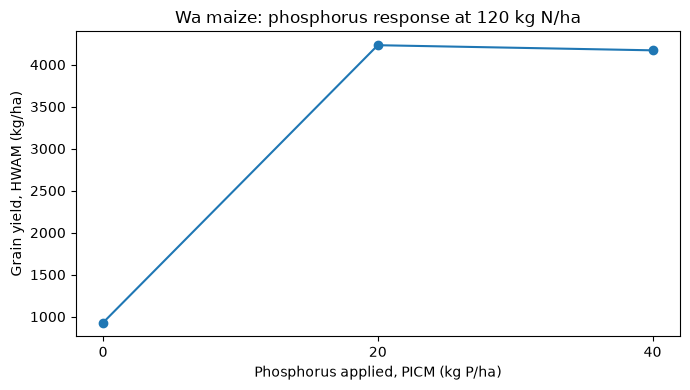

In [9]:
# Plot grain yield against the applied phosphorus rate.
comparison = results.loc[results["scenario"] != "base"].copy()
ax = comparison.plot(x="PICM", y="HWAM", marker="o", legend=False, figsize=(7, 4))
ax.set(xlabel="Phosphorus applied, PICM (kg P/ha)", ylabel="Grain yield, HWAM (kg/ha)",
       title="Wa maize: phosphorus response at 120 kg N/ha", xticks=p_rates)
plt.tight_layout()
plt.show()

🌱 Crop idea  
The curve is surprising: 40 kg P/ha gives 61 kg/ha less grain than 20, even though biomass increases from 12,928 to 13,214 kg/ha.
These outputs do not establish why grain yield falls slightly; this one season does not identify a generally optimal P rate.

Plot daily aboveground biomass (`CWAD`, kg/ha) to compare growth across the three P rates.

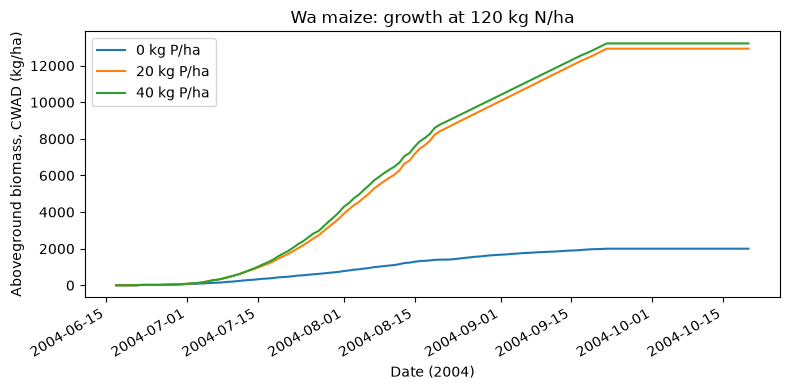

In [10]:
# Compare daily biomass from the labelled scenarios.
fig, ax = plt.subplots(figsize=(8, 4))
for row in rows:
    if row["scenario"] != "base":
        growth = dl.to_dataframe(dl.read_plant_growth(row["run_dir"]))
        ax.plot(growth["DATE"], growth["CWAD"], label=f'{row["PICM"]} kg P/ha')
ax.set(xlabel="Date (2004)", ylabel="Aboveground biomass, CWAD (kg/ha)",
       title="Wa maize: growth at 120 kg N/ha")
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Read a compact warning excerpt to see DSSAT adjustments that accompany the successful 0-P run.

In [11]:
# Show the relevant stock-case warnings without the machine-path header.
zero_row = next(row for row in rows if row["fertilizer"] == 0)
warning_file = zero_row["run_dir"] / "WARNING.OUT"
warning_lines = warning_file.read_text(encoding="utf-8").splitlines()
phrases = ("P content of residue was changed", "Value read from file", "Value changed to",
           "extremely low nutrient concentration", "forcing deep placement")
print("Warnings:", warning_file.relative_to(HERE).as_posix())
print("\n".join(dict.fromkeys(line.strip() for line in warning_lines
                              if any(phrase in line for phrase in phrases))))

Warnings: runs/dssat_sim_2026-10-06_203855-2/dssat_run_2026-10-06_203855/WARNING.OUT
P content of residue was changed from value in initial conditions
- Value read from file               : 0.100%
- Value changed to                   : 0.256%
residue with an extremely low nutrient concentration.
Model is forcing deep placement into second layer.


🌱 Crop idea  
DSSAT changes the stock residue P content from 0.100% to 0.256% and forces deep N placement into the second soil layer.
The same warnings occur at all three P rates; keep them in mind when interpreting this stock case.

## Your turn

Compare zero P with one new P rate at the same 120 kg N/ha, soil analysis and initial conditions.

Hint: Choose a whole-number P rate from 1 to 40 kg P/ha, then run this cell.

In [12]:
# Choose a P rate and rebuild both schedules for an independent comparison.
chosen_p = 30
exercise_inputs = {
    "filex": RUNS / "GHWA0401.MZX",
    "weather": [RUNS / "GHWA0301.WTH", RUNS / "GHWA0401.WTH"],
    "soil": RUNS / "GH.SOL",
    "executable": dssat,
}
exercise_n = [
    {"date": "2004-07-05", "material": "FE005", "application": "AP007", "depth": 5, "n": 60, "p": 0},
    {"date": "2004-07-15", "material": "FE005", "application": "AP007", "depth": 5, "n": 60, "p": 0},
]
exercise_schedules = {rate: [
    {"date": "2004-06-15", "material": "FE013", "application": "AP004", "depth": 10, "n": 0, "p": rate},
    *exercise_n,
] for rate in (0, chosen_p)}
exercise_experiment = {"treatments": {7: {
    "controls": {"phosphorus": "Y"}, "fertilizer": exercise_schedules[0],
}}}
exercise_rows = dl.run_sweep(**exercise_inputs, treatments=[7], management=exercise_experiment,
                             factors={"fertilizer": exercise_schedules})
exercise_results = dl.to_dataframe(exercise_rows)
exercise_comparison = exercise_results.loc[
    exercise_results["scenario"] != "base", ["PICM", "NICM", "HWAM"]
].copy()
zero_yield = exercise_comparison.loc[exercise_comparison["PICM"] == 0, "HWAM"].iloc[0]
exercise_comparison["Yield gain over zero P (kg/ha)"] = exercise_comparison["HWAM"] - zero_yield
exercise_comparison

,PICM,NICM,HWAM,Yield gain over zero P (kg/ha)
1,0,120,929,0
2,30,120,4195,3266


## Recap

- Keep one treatment's soil analysis and initial conditions fixed to compare fertilizer P rates.
- `phosphorus: "Y"` enables P simulation; complete fertilizer schedules hold N at 120 kg/ha.
- Summary tables and inline growth plots show a P response, with a small grain-yield decline from 20 to 40 kg P/ha in this season.

Next: [13 · Seasonal analysis and economics](../13_seasonal_economics/lesson.ipynb) (available when lesson 13 is added).